# PHYS-467 Machine Learning for Physisicst 

Back to linear regression - Solutions

***Exercise 4.1: maximum likelihood and linear regression***

1.   Write a function generating the synthetic dataset $D = \left \{ x^{\mu}, y^
{\mu} \right\}_{\mu = 1}^n$, with $x^{\mu} \sim \mathcal{N}\left(0,1\right)$, $y^{\mu} = w_{\star} x^{\mu} + \mathcal{N}\left(0,\sigma^2\right)$ and $ w_{\star} \in \mathbb{R}$ and plot it;
2.   Infer the parameter $w_{\star}$ by linear regression;
3.   Verify that the maximum of the log-likelihood coincides with the least squares solution.










In [ ]:
import numpy as np
import matplotlib.pyplot as plt 

*Exercise 4.1 - 1: construction of the synthetic dataset* 

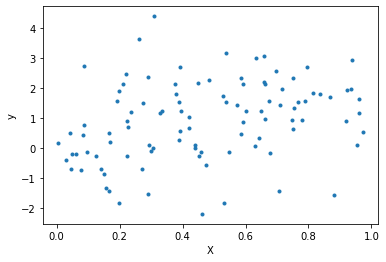

In [ ]:
def generate_data(n, w_star, sigma):
  """
  This function generates a synthetic dataset with input x normal gaussian and labels y = w_star * x + noise
    Input:  n = number of samples; w_star = ground truth coefficient, sigma = standard deviation of the noise
    Output: D = {X,y} = synthetic dataset
  """
  noise = np.sqrt(sigma) * np.random.randn(n, 1)
  X = np.random.rand(n, 1)
  y = w_star * X + noise 
  return X, y

# definition of the hyper-parameters:
n = 100 #number of samples
w_star = 2. #ground truth
sigma = 2. #standard deviation of the noise

# generation of the synthetic dataset
X, y = generate_data(n, w_star, sigma)

# plot labels y as a function of the input data points x
plt.plot(X, y, '.')
plt.xlabel('X')
plt.ylabel('y');

*Exercise 4.1 - 2: estimation of the ground truth parameter by least squares*

In [ ]:
# Linear regression estimator
def linear_regression_estimator(X, y):
    """
    This function infer the ground truth parameter w_star given the dataset D = {X,y}.
      Input:  synthetic dataset D = {X,y}
      Output: least square estimation of the ground truth parameters w_star 
    """
    w_est = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
    return w_est

# estimation of the ground truth w_star by least squares
w_est = linear_regression_estimator(X, y)

*Exercise 4.1 - 3: check that the least square solution coincides with the maximum of the log-likelihood* 

In [ ]:
# definition of the log-likelihood
def loglikelihood(w, X, y, sigma):
  """
  This function computes the log-likelihood given the synthetic dataset D = {X,y}.
    Input: w = slope of the line;
           D = {X,y} = synthetic dataset;
           sigma = variance of the noise.
    Output: log-likelihood
  """
  n = len(y) # number of samples
  loglikelihood = - np.sum((y - w*X)**2)/(2*sigma) - (n/2) * np.log(2*np.pi*sigma) # computes the log-likelihood 
  return loglikelihood

# evaluation of the log-likelihood on several w's
w_vals = np.linspace(-5, 10, 100) # generates 100 equally spaced values of w in the interval [-5,10].
loglikelihood_vals = [loglikelihood(w, X, y, sigma) for w in w_vals] # for each w computes the corresponding value of the log-likelihood

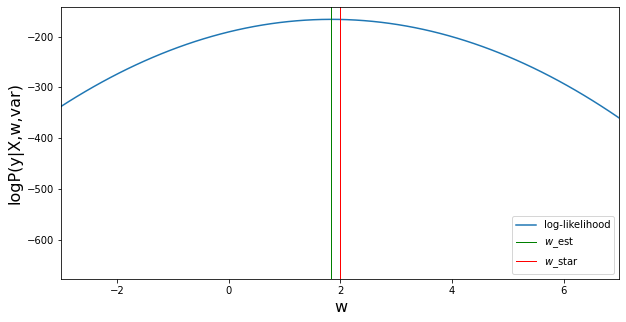

In [ ]:
# plot the log-likelihood and show that w_est coincides with its maximum 

plt.figure(figsize=(10,5)) # generate the figure
plt.plot(w_vals, loglikelihood_vals, label = "log-likelihood") # plot the log-likelihood as a function of w

plt.axvline(w_est, color="g", linestyle="-", label=r"$w$_est", linewidth = 1.0) # plot the vertical line corresponding to the linear regression estimator
plt.axvline(w_star, color="r", linestyle="-", label=r"$w$_star", linewidth = 1.0) # plot the vertical line corresponding to the ground truth 


plt.xlim([-3, 7]) # set the x range in the plot
plt.xlabel("w",fontsize=16) # set the name of the x-axis
plt.ylabel("logP(y|X,w,var)", fontsize=16) # set the name of the y-axis
plt.legend(loc = 'lower right') # determine the position of the legend


***Exercise 4.2: $L_2$ regularization as a prior***

1.   Load the diabetes database from scikit-learn;
2.   Split the dataset in train, test and validation set;
3.   Plot the components of the estimator as a function of the regularization;
4.   Determine the optimal value of the regularization;
5.   Compute the test error and plot actual test labels versus predictions to check their correlation.

*Exercise 4.2 -- 1: Load the diabetes dataset*

In [ ]:
# Import diabetes dataset from scikit-learn toy-dataset examples
from sklearn.datasets import load_diabetes

In [ ]:
# Load boston dataset
diabetes = load_diabetes()

# Check what it contains
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

  :Number of Instances: 442

  :Number of Attributes: First 10 columns are numeric predictive values

  :Target: Column 11 is a quantitative measure of disease progression one year after baseline

  :Attribute Information:
      - Age
      - Sex
      - Body mass index
      - Average blood pressure
      - S1
      - S2
      - S3
      - S4
      - S5
      - S6

Note: Each of these 10 feature variables have been mean centered and scaled by the standard deviation times `n_samples` (i.e. the sum of squares of each column totals 1).

Source URL:
https://www4.stat.ncsu.edu/~boos/var.select/diabetes.html

For more information see:
Bra

In [ ]:
# Extract the dataset
X = diabetes.data 
y = diabetes.target
print("the dimension of X is (n, d)=",X.shape, "the dimension of y is n=",y.shape) # print the dimension of the X matrix and the y vector

the dimension of X is (n, d)= (442, 10) the dimension of y is n= (442,)


In [ ]:
import pandas as pd
import seaborn as sns

In [ ]:
# create a dictionary of features

df = pd.DataFrame(X, columns = ["age", "sex", "body_mass", "blood_pressure", "total_serum_cholesterol", "low_densisty_lipoproteins", "high_density_lipoproteins", "total_cholesterol", "tryglicerides_level", "blood_sugar_level"])
print(df.head()) # print the dictionary

        age       sex  ...  tryglicerides_level  blood_sugar_level
0  0.038076  0.050680  ...             0.019908          -0.017646
1 -0.001882 -0.044642  ...            -0.068330          -0.092204
2  0.085299  0.050680  ...             0.002864          -0.025930
3 -0.089063 -0.044642  ...             0.022692          -0.009362
4  0.005383 -0.044642  ...            -0.031991          -0.046641

[5 rows x 10 columns]


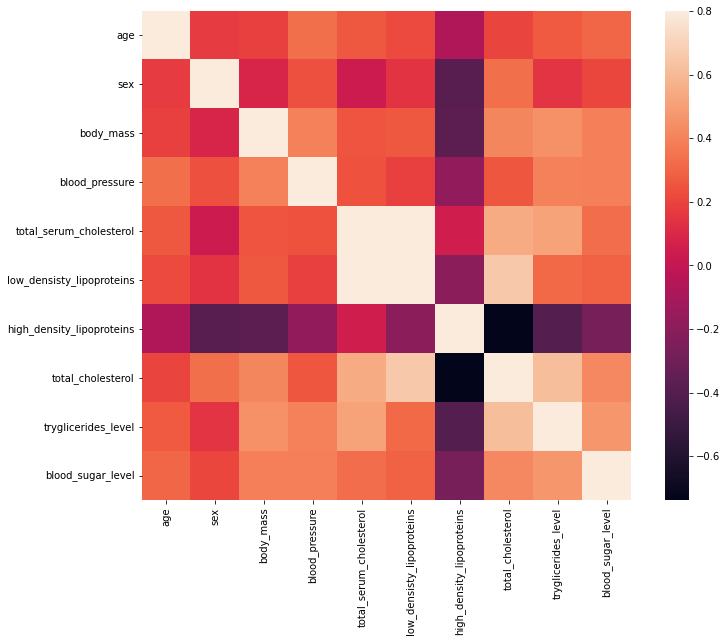

In [ ]:
corr_mat = df.corr() # compute the correlation matrix of the features vectors
fig, ax = plt.subplots(figsize = (12,9)) # create the figure object
sns.heatmap(corr_mat, vmax = 0.8, square = True) # plot the heat-map

*Exercise 4.2 -- 2: split the dataset in train, test and validation set*

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# Split data in training, test and validation set

X_train, X_validation, y_train, y_validation = train_test_split(X, y, test_size = 0.2, random_state = 42) 
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size = 0.2, random_state = 42)

*Exercise 4.2 -- 3: estimator components as a function of the regularization strength*

In [ ]:
import pandas as pd
from sklearn.linear_model import Ridge

In [ ]:
# Check how the components of the estimator evolve with the regularization strength

def weights_vs_regularization(lambdas):
  """
  This function computes the estimator for several regulariazation strengths and store the result in a pandas dataframe.
    Input:  lambdas = array of regularization strength on which to evaluate the estimator;
    Output: res = pandas dataframe containing the estimator components for each regularization strength
  """

  # initialize an empty dictionary
  res = {'lambda': [], 'W1': [], 'W2': [], 'W3': [], 'W4': [], 'W5': [], 'W6': [], 'W7': [], 'W8': [], 'W9': [], 'W10': []}
  for lamb in lambdas: # loop over lambdas
    res["lambda"].append(lamb) # populate the first colum of the dictionary with the lambda values
    W = Ridge(alpha=lamb, fit_intercept = True).fit(X_train, y_train).coef_ # infer the estimator by ridge regression at every lambda plus the bias
    res["W1"].append(W[0]) # populate all the other columns of the dictionary with the components of the estimator
    res["W2"].append(W[1])
    res["W3"].append(W[2])
    res["W4"].append(W[3])
    res["W5"].append(W[4])
    res["W6"].append(W[5])
    res["W7"].append(W[6])
    res["W8"].append(W[7])
    res["W9"].append(W[8])
    res["W10"].append(W[9])

  res = pd.DataFrame.from_dict(res) # translates the dictionary into a pandas dataframe  
  return res

lambdas = np.arange(0.1, 10., 0.1) # array of lambdas
res = weights_vs_regularization(lambdas) # infer the components of the estimator as a function of the regularization strength
res.to_csv("./weights_vs_regularization_l2.csv", mode = 'w', index = False) # write the pandas dataframe into *.csv file

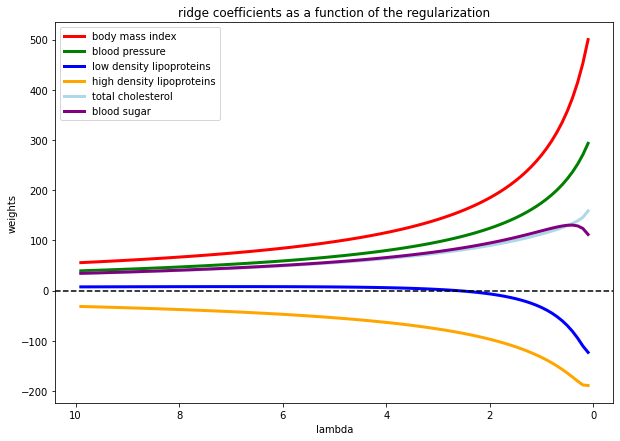

In [ ]:
# Plot the result

fig, ax = plt.subplots(figsize=(10,7)) # initialize an empty figure and axes object
res = pd.read_csv("./weights_vs_regularization_l2.csv") # read the content of the *.csv file

res.plot(x='lambda',
         y='W3',
         color = 'red',
         lw = 3, # linewidth
         ax=ax, # to plot in the same figure
         label='body mass index') # plot the results with matplotlib through pandas


res.plot(x='lambda',
         y='W4',
         color = 'green',
         lw = 3,
         ax=ax,
         label='blood pressure')


res.plot(x='lambda',
         y='W6',
         color = 'blue',
         lw = 3,
         ax=ax,
         label='low density lipoproteins')


res.plot(x='lambda',
         y='W7',
         color = 'orange',
         lw = 3,
         ax=ax,
         label='high density lipoproteins')


res.plot(x='lambda',
         y='W8',
         color = 'lightblue',
         lw = 3,
         ax=ax,
         label='total cholesterol')

res.plot(x='lambda',
         y='W10',
         color = 'purple',
         lw = 3,
         ax=ax,
         label='blood sugar')

ax.axhline(0., color='k', linestyle='--') # plot an horizontal line on zero

ax.set_title("ridge coefficients as a function of the regularization") # set the plot title
ax.invert_xaxis() # sort the x axis in descending order
ax.set_ylabel("weights") # set the name of the y axis
ax.set_xlabel("lambda") # set the name of the x axis
#ax.set_xlim(0.3,10**(-10)) # set the range of the x axis
ax.legend(loc = 'upper left') # specify the position of the legend

*Exercise 4.2 -- 4: estimate the optimal regularization strength*

In [ ]:
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error

In [ ]:
# define the validation error

def validation_error_l2(lamb, X_train, y_train, X_validation, y_validation):
  """
  This function computes the error on the validation set.
    Input: lamb = regularization strength;
           X_train, y_train = training set;
           X_validation, y_validation = validation set. 
    Output: val_err = validation error
  """
  ridge = Ridge(alpha=lamb).fit(X_train, y_train) # fit the data by ridge regularization
  W_est = ridge.coef_ # extract the estimator 
  bias = ridge.intercept_ # extract the bias
  y_validation_pred = X_validation.dot(W_est) + bias
  val_err = mean_squared_error(y_validation, y_validation_pred) # evaluate the validation error
  return val_err

In [ ]:
# estimate the optimal regularization on the validation set

opt_result = minimize(validation_error_l2,x0=1.,args=(X_train, y_train, X_validation, y_validation), bounds = [(0., 10.)]) # look for the optimal value of lambda optimizing the generalization error

print(opt_result)

lamb_optimal = opt_result['x'][0] # optimal lambda
val_err_optimal = opt_result['fun'] # optimal validation error

      fun: 2863.125639911687
 hess_inv: <1x1 LbfgsInvHessProduct with dtype=float64>
      jac: array([-0.00013642])
  message: b'CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH'
     nfev: 24
      nit: 4
   status: 0
  success: True
        x: array([0.13146809])


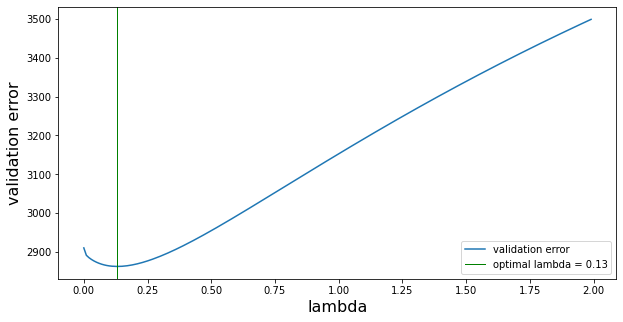

In [ ]:
# plot the validation error as a function of the regularization strength

lambdas = np.arange(0., 2., 0.01) # array of lambda values
val_error = [validation_error_l2(lamb, X_train, y_train, X_validation, y_validation) for lamb in lambdas]

plt.figure(figsize=(10,5)) # generate the figure
plt.plot(lambdas, val_error, label = "validation error") # plot the log-likelihood as a function of w

plt.axvline(lamb_optimal, color="g", linestyle="-", label=r"optimal lambda = 0.13", linewidth = 1.0) # plot the vertical line corresponding to the linear regression estimator


#plt.xlim([-0.2, 0.2]) # set the x range in the plot
plt.xlabel("lambda",fontsize=16) # set the name of the x-axis
plt.ylabel("validation error", fontsize=16) # set the name of the y-axis
plt.legend(loc = 'lower right') # determine the position of the legend

*Exercise 4.2 -- 5: compute the test error and check correlation between model predictions and true labels*

In [ ]:
# compute the error on the test set
ridge = Ridge(alpha=lamb_optimal).fit(X_train, y_train)
W_opt = ridge.coef_ # infer the estimator by ridge regularization 
bias = ridge.intercept_ # infer the bias
y_test_pred = X_test.dot(W_opt) + bias # compute the model predictions on the test set 
test_err = mean_squared_error(y_test, y_test_pred) # error on the test set 

print("test error = ", test_err)

test error =  2853.548429606596


Text(0, 0.5, 'true test labels')

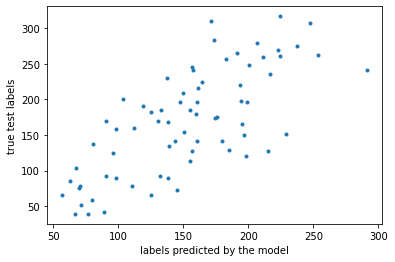

In [ ]:
# check correlations between model predictions and true labels

plt.plot(y_test_pred, y_test, '.')
plt.xlabel('labels predicted by the model')
plt.ylabel('true test labels')

***Exercise 4.3: $L_1$ regularization as a prior***

1.   Repeat all points {3-5} of exercise 4.2 with lasso

*Exercise 4.3 -- 3: estimator components as a function of the regularization strength*

In [ ]:
from sklearn.linear_model import Lasso


In [ ]:
# Check how the components of the estimator evolve with the regularization strength

def weights_vs_regularization(lambdas):
  """
  This function computes the estimator for several regulariazation strengths and store the result in a pandas dataframe.
    Input:  lambdas = array of regularization strength on which to evaluate the estimator;
    Output: res = pandas dataframe containing the estimator components for each regularization strength
  """

  # initialize an empty dictionary
  res = {'lambda': [], 'W1': [], 'W2': [], 'W3': [], 'W4': [], 'W5': [], 'W6': [], 'W7': [], 'W8': [], 'W9': [], 'W10': []}
  for lamb in lambdas: # loop over lambdas
    res["lambda"].append(lamb) # populate the first colum of the dictionary with the lambda values
    W = Lasso(alpha=lamb, max_iter = 10000).fit(X_train, y_train).coef_ # infer the estimator by lasso at every lambda
    res["W1"].append(W[0]) # populate all the other columns of the dictionary with the components of the estimator
    res["W2"].append(W[1])
    res["W3"].append(W[2])
    res["W4"].append(W[3])
    res["W5"].append(W[4])
    res["W6"].append(W[5])
    res["W7"].append(W[6])
    res["W8"].append(W[7])
    res["W9"].append(W[8])
    res["W10"].append(W[9])

  res = pd.DataFrame.from_dict(res) # translate the dictionary into a pandas dataframe  
  return res

lambdas = np.arange(0.1, 5., 0.1) # array of lambdas
res = weights_vs_regularization(lambdas) # infer the components of the estimator as a function of the regularization strength
res.to_csv("./weights_vs_regularization_l1.csv", mode = 'w', index = False) # write the pandas dataframe into *.csv file

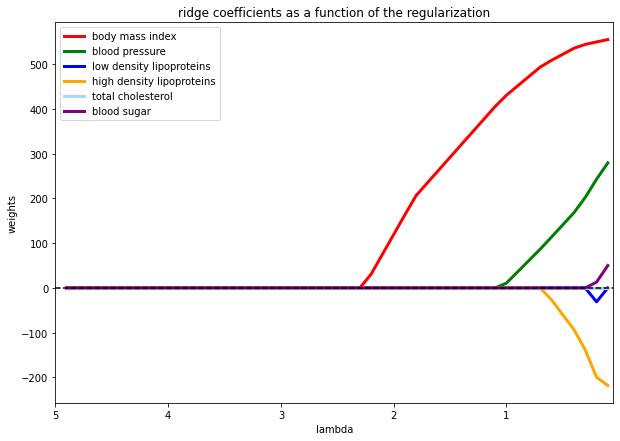

In [ ]:
# Plot the result

fig, ax = plt.subplots(figsize=(10,7)) # initialize an empty figure and axes object
res = pd.read_csv("./weights_vs_regularization_l1.csv") # read the content of the *.csv file

res.plot(x='lambda',
         y='W3',
         color = 'red',
         lw = 3, # linewidth
         ax=ax, # to plot in the same figure
         label='body mass index') # plot the results with matplotlib through pandas


res.plot(x='lambda',
         y='W4',
         color = 'green',
         lw = 3,
         ax=ax,
         label='blood pressure')


res.plot(x='lambda',
         y='W6',
         color = 'blue',
         lw = 3,
         ax=ax,
         label='low density lipoproteins')


res.plot(x='lambda',
         y='W7',
         color = 'orange',
         lw = 3,
         ax=ax,
         label='high density lipoproteins')


res.plot(x='lambda',
         y='W8',
         color = 'lightblue',
         lw = 3,
         ax=ax,
         label='total cholesterol')

res.plot(x='lambda',
         y='W10',
         color = 'purple',
         lw = 3,
         ax=ax,
         label='blood sugar')

ax.axhline(0., color='k', linestyle='--') # plot an horizontal line on zero

ax.set_title("ridge coefficients as a function of the regularization") # set the plot title
ax.invert_xaxis() # sort the x axis in descending order
ax.set_ylabel("weights") # set the name of the y axis
ax.set_xlabel("lambda") # set the name of the x axis
ax.set_xlim(5.,0.05) # set the range of the x axis
ax.legend(loc = 'upper left') # specify the position of the legend

*Exercise 4.3 -- 4: estimate the optimal regularization strength*

In [ ]:
# define the validation error

def validation_error_l1(lamb, X_train, y_train, X_validation, y_validation):
  """
  This function computes the error on the validation set.
    Input: lamb = regularization strength;
           X_train, y_train = training set;
           X_validation, y_validation = validation set. 
  """
  lasso = Lasso(alpha=lamb).fit(X_train, y_train) # fit the data by lasso regularization 
  W_est = lasso.coef_ # extract the estimator
  bias = lasso.intercept_ # extract the bias
  y_validation_pred = X_validation.dot(W_est) + bias
  val_err = mean_squared_error(y_validation, y_validation_pred) # evaluate the validation error
  return val_err

In [ ]:
# estimate the optimal regularization on the validation set

opt_result = minimize(validation_error_l1,x0=1.,args=(X_train, y_train, X_validation, y_validation), bounds = [(0., 10.)]) # look for the optimal value of lambda optimizing the generalization error

print(opt_result)

lamb_optimal = opt_result['x'][0] # optimal lambda
val_err_optimal = opt_result['fun'] # optimal validation error

      fun: 2795.0312077549734
 hess_inv: <1x1 LbfgsInvHessProduct with dtype=float64>
      jac: array([0.0007276])
  message: b'CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH'
     nfev: 18
      nit: 6
   status: 0
  success: True
        x: array([0.14396803])


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:10: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  # Remove the CWD from sys.path while we load stuff.
/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_coordinate_descent.py:476: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  positive)
/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_coordinate_descent.py:476: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 408730.77043967554, tolerance: 174.13458049645394
  positive)
/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_coordinate_descent.py:476: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 37016.168586228974, tolerance: 174.13458049645394
  positive)


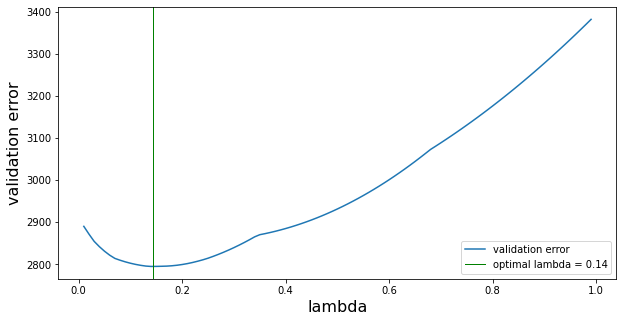

In [ ]:
# plot the validation error as a function of the regularization strength

lambdas = np.arange(0.01, 1., 0.01) # array of lambda values
val_error = [validation_error_l1(lamb, X_train, y_train, X_validation, y_validation) for lamb in lambdas]

plt.figure(figsize=(10,5)) # generate the figure
plt.plot(lambdas, val_error, label = "validation error") # plot the log-likelihood as a function of w

plt.axvline(lamb_optimal, color="g", linestyle="-", label=r"optimal lambda = 0.14", linewidth = 1.0) # plot the vertical line corresponding to the linear regression estimator


#plt.xlim([0.0, 5.]) # set the x range in the plot
plt.xlabel("lambda",fontsize=16) # set the name of the x-axis
plt.ylabel("validation error", fontsize=16) # set the name of the y-axis
plt.legend(loc = 'lower right') # determine the position of the legend

*Exercise 4.3 -- 5: compute the test error and check correlation between model predictions and true labels*

In [ ]:
# compute the error on the test set

lasso = Lasso(alpha=lamb_optimal).fit(X_train, y_train) # fit the data by lasso regularization
W_opt = lasso.coef_ # extract the estimator  
bias = lasso.intercept_ # extract the bias
y_pred_test = X_test.dot(W_opt) + bias
test_err = mean_squared_error(y_test, y_pred_test) # error on the test set 

print("test error = ", test_err)

test error =  2829.4791054285024


Text(0, 0.5, 'true test labels')

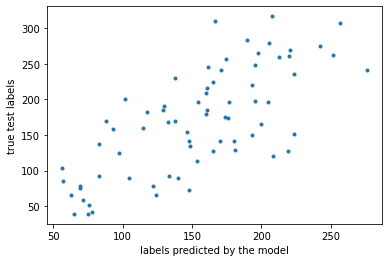

In [ ]:
# plot the actual test labels versus the predicted one to check their correlation

plt.plot(y_pred_test, y_test, '.')
plt.xlabel('labels predicted by the model')
plt.ylabel('true test labels')